In [236]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import ast
from sklearn.metrics import accuracy_score
import copy
from sklearn.metrics import (roc_auc_score, precision_score, recall_score, f1_score,average_precision_score)
from sklearn.neural_network import MLPClassifier

In [237]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import SplineTransformer, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegressionCV
from sklearn.pipeline import make_pipeline
import matplotlib.pyplot as plt

In [238]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error,root_mean_squared_error
from scipy.stats import spearmanr
from sklearn.metrics import confusion_matrix
from sklearn.utils.class_weight import compute_sample_weight

# Load

In [239]:
newness = np.load("newness_2024.npy",allow_pickle=True)
surprise = np.load("surprise_2024.npy",allow_pickle=True)
value = np.load("value_2024.npy",allow_pickle=True)

In [240]:
BASELINE_YEAR=1600

In [241]:
gold_set_70 = pd.read_excel("golden_set_move_creative_70.xlsx")

In [242]:
creative_70 = np.load("creativity_70_full_prob.npy",allow_pickle=True)

In [243]:
artnet_2024 = pd.read_excel("Artnet_Europe_2024_merged.xlsx")

In [244]:
merged_df = pd.merge(gold_set_70, artnet_2024[["artwork id","artist id","year born","workyear modifier","price","artist",'est lo usd','est hi usd', 'sale price usd']], on='artwork id', how='left')

In [245]:
artist_list = ["Pierre-Auguste Renoir"]
keep_list = merged_df["artist"].isin(artist_list)
merged_df = merged_df[keep_list]
creative_70 = creative_70[keep_list]

In [246]:
merged_df.shape

(189, 33)

In [247]:
newness_df = np.zeros(merged_df.shape[0], dtype=object)
surprise_df = np.zeros(merged_df.shape[0], dtype=object)
value_df = np.zeros(merged_df.shape[0], dtype=object)
for i in range(merged_df.shape[0]):
    row_index = merged_df.index[i]
    newness_df[i] =newness[row_index]
    surprise_df[i] =surprise[row_index]
    value_df[i] = value[row_index]

# Correlation

In [248]:
new_vs_surprise, pval = spearmanr(newness,surprise)
print(f"The Correlation between newness and Surprise is {new_vs_surprise}")

The Correlation between newness and Surprise is 0.29855096413658955


In [249]:
new_vs_value, pval = spearmanr(newness,value)
print(f"The Correlation between newness and value is {new_vs_value}")

The Correlation between newness and value is 0.04208609603505632


In [250]:
value_vs_surprise, pval = spearmanr(value,surprise)
print(f"The Correlation between surprise and value is {value_vs_surprise}")

The Correlation between surprise and value is 0.03080979637171211


# Cut off 0.85

## Basic
Balanced + Normalized (max min)

In [251]:
newness_min=np.min(newness_df)
newness_max = np.max(newness_df)
newness_normalized=(newness_df - newness_min)/(newness_max-newness_min)

In [252]:
surprise_min=np.min(surprise_df)
surprise_max = np.max(surprise_df)
surprise_normalized=(surprise_df - surprise_min)/(surprise_max-surprise_min)

In [253]:
value_min=np.min(value_df)
value_max = np.max(value_df)
value_normalized=(value_df - value_min)/(value_max-value_min)

In [254]:
creativity_min = np.min(creative_70)
creativity_max =np.max(creative_70)
creativity_normalized = (creative_70 - creativity_min)/(creativity_max-creativity_min)

In [255]:
print(f"Creativity Minimum: {creativity_min}. Creativity Max: {creativity_max}.")

Creativity Minimum: 0.7874627846114851. Creativity Max: 0.99027119484493.


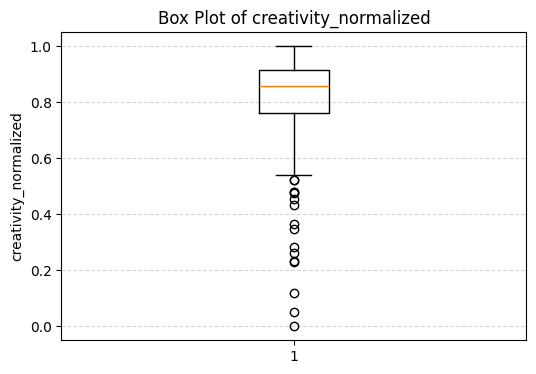

In [256]:
plt.figure(figsize=(6, 4))
plt.boxplot(creativity_normalized, vert=True, showfliers=True)
plt.title("Box Plot of creativity_normalized")
plt.ylabel("creativity_normalized")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [257]:
percentile = (creativity_normalized <= 0.85).mean() * 100
percentile

np.float64(46.56084656084656)

In [258]:
y = [1 if i>=0.85 else 0 for i in creativity_normalized]
X = np.stack((newness_normalized, surprise_normalized,value_normalized), axis=1)

In [259]:
np.sum(y)/len(y)

np.float64(0.5343915343915344)

In [260]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, random_state=23,stratify=y)

In [261]:
model = LogisticRegression(max_iter=10000, random_state=0,class_weight="balanced")
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,0
,solver,'lbfgs'
,max_iter,10000
,multi_class,'deprecated'


In [262]:
acc = accuracy_score(y_test,model.predict(X_test)) * 100
print(f"Test Logistic Regression model accuracy: {acc:.2f}%")
auc = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
print("Test AUC:", auc)
precision = precision_score(y_test, model.predict(X_test))
print("Test Precision:", precision)
recall = recall_score(y_test, model.predict(X_test))
print("Test Recall:", recall)
f1 = f1_score(y_test, model.predict(X_test))
print("Test F1:", f1)

Test Logistic Regression model accuracy: 39.47%
Test AUC: 0.4666666666666667
Test Precision: 0.3333333333333333
Test Recall: 0.15
Test F1: 0.20689655172413793


In [263]:
confusion_matrix(y_test, model.predict(X_test))

array([[12,  6],
       [17,  3]])

## Splines 
Splines + Balanced + Normalized (max min)

In [264]:
newness_min=np.min(newness_df)
newness_max = np.max(newness_df)
newness_normalized=(newness_df - newness_min)/(newness_max-newness_min)
surprise_min=np.min(surprise_df)
surprise_max = np.max(surprise_df)
surprise_normalized=(surprise_df - surprise_min)/(surprise_max-surprise_min)
value_min=np.min(value_df)
value_max = np.max(value_df)
value_normalized=(value_df - value_min)/(value_max-value_min)
creativity_min = np.min(creative_70)
creativity_max =np.max(creative_70)
creativity_normalized = (creative_70 - creativity_min)/(creativity_max-creativity_min)

In [265]:
print(f"Creativity Minimum: {creativity_min}. Creativity Max: {creativity_max}.")

Creativity Minimum: 0.7874627846114851. Creativity Max: 0.99027119484493.


In [266]:
y = [1 if i>=0.85 else 0 for i in creativity_normalized]
X = np.stack((newness_normalized, surprise_normalized,value_normalized), axis=1)

In [267]:
np.sum(y)/len(y)

np.float64(0.5343915343915344)

In [268]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, random_state=23,stratify=y)

In [269]:
preprocess = ColumnTransformer([
    ("spline", SplineTransformer(
        degree=3,           # cubic
        n_knots=8,          # tune with CV (e.g., 5–10 common)
        extrapolation="linear",
        include_bias=False  # avoid intercept duplication
    ), [1,2]),
], remainder="drop")

In [270]:
model = make_pipeline(
    preprocess,
    LogisticRegressionCV(cv=5, max_iter=5000, n_jobs=-1,class_weight="balanced")
)

In [271]:
model.fit(X_train, y_train)

,steps,"[('columntransformer', ...), ('logisticregressioncv', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('spline', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [272]:
y_pred = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:,1]

In [273]:
acc = accuracy_score(y_test,y_pred) * 100
print(f"Test Logistic Regression model accuracy: {acc:.2f}%")
auc = roc_auc_score(y_test, y_pred_prob )
print("Test AUC:", auc)
precision = precision_score(y_test,model.predict(X_test))
print("Test Precision:", precision)
recall = recall_score(y_test, y_pred)
print("Test Recall:", recall)
f1 = f1_score(y_test, y_pred)
print("Test F1:", f1)

Test Logistic Regression model accuracy: 73.68%
Test AUC: 0.6305555555555556
Test Precision: 0.8571428571428571
Test Recall: 0.6
Test F1: 0.7058823529411765


In [274]:
confusion_matrix(y_test, y_pred)

array([[16,  2],
       [ 8, 12]])

## Neural Network

In [275]:
newness_min=np.min(newness_df)
newness_max = np.max(newness_df)
newness_normalized=(newness_df - newness_min)/(newness_max-newness_min)
surprise_min=np.min(surprise_df)
surprise_max = np.max(surprise_df)
surprise_normalized=(surprise_df - surprise_min)/(surprise_max-surprise_min)
value_min=np.min(value_df)
value_max = np.max(value_df)
value_normalized=(value_df - value_min)/(value_max-value_min)
creativity_min = np.min(creative_70)
creativity_max =np.max(creative_70)
creativity_normalized = (creative_70 - creativity_min)/(creativity_max-creativity_min)

In [276]:
constant = np.ones(len(surprise_df))

In [277]:
y = [1 if i>=0.85 else 0 for i in creativity_normalized]
X = np.stack((newness_normalized, surprise_normalized,value_normalized), axis=1)

In [278]:
np.sum(y)/len(y)

np.float64(0.5343915343915344)

In [279]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, random_state=23,stratify=y)

In [280]:
alphas = [1e-6,3e-6,5e-6,7e-6,9e-6,1e-5]
layers=[(4,4),(4,8),(8,8),(8,16),(16,16),(16,32)]

In [281]:
result=[]
best_alpha=None
best_layer=None
best_score=None
for alpha in alphas:
    for layer in layers:
        model = MLPClassifier(solver='lbfgs', alpha=alpha,
                    hidden_layer_sizes=layer, random_state=1,max_iter=5000)
        X_train1, X_val, y_train1, y_val = train_test_split(X_train,y_train, test_size=0.20, random_state=23,stratify=y_train)
        sample_weights = compute_sample_weight(class_weight='balanced', y=y_train1)
        
        model.fit(X_train1, y_train1, sample_weight = sample_weights)

        
            
        y_pred = model.predict(X_val)
        y_pred_prob = model.predict_proba(X_val)[:,1]
        acc = accuracy_score(y_val,y_pred) * 100
        #print(f"Test Logistic Regression model accuracy: {acc:.2f}%")
        auc = roc_auc_score(y_val, y_pred_prob)
        #print("Test AUC:", auc)
        precision = precision_score(y_val,y_pred)
        #print("Test Precision:", precision)
        recall = recall_score(y_val, y_pred)
        #print("Test Recall:", recall)
        f1 = f1_score(y_val, y_pred)

        if best_alpha==None:
            best_alpha = alpha
            best_layer = layer
            best_score = auc
        elif best_score > auc:
            best_alpha = alpha
            best_layer = layer
            best_score = auc
            
        
        result.append({'alpha':alpha,'layer':layer,'acc':acc,'auc':auc,'precision':precision,'recall':recall,'f1':f1,'conf_matrix':confusion_matrix(y_val, y_pred)})
        #print("Test F1:", f1)

/opt/anaconda3/envs/Creativity/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/Creativity/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/Creativity/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [282]:
model = MLPClassifier(solver='lbfgs', alpha=best_alpha,
                    hidden_layer_sizes=best_layer, random_state=1,max_iter=5000)
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)
model.fit(X_train, y_train, sample_weight = sample_weights)
y_pred = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:,1]
acc = accuracy_score(y_test,y_pred) * 100
print(f"Test Logistic Regression model accuracy: {acc:.2f}%")
auc = roc_auc_score(y_test, y_pred_prob)
print("Test AUC:", auc)
precision = precision_score(y_test,y_pred)
print("Test Precision:", precision)
recall = recall_score(y_test, y_pred)
print("Test Recall:", recall)
f1 = f1_score(y_test, y_pred)
print("Test F1:", f1)

Test Logistic Regression model accuracy: 42.11%
Test AUC: 0.4305555555555556
Test Precision: 0.4583333333333333
Test Recall: 0.55
Test F1: 0.5


In [283]:
confusion_matrix(y_test, y_pred)

array([[ 5, 13],
       [ 9, 11]])

# Cut off 0.80

## Basic
Balanced + Normalized (max min)

In [284]:
newness_min=np.min(newness_df)
newness_max = np.max(newness_df)
newness_normalized=(newness_df - newness_min)/(newness_max-newness_min)

In [285]:
surprise_min=np.min(surprise_df)
surprise_max = np.max(surprise_df)
surprise_normalized=(surprise_df - surprise_min)/(surprise_max-surprise_min)

In [286]:
value_min=np.min(value_df)
value_max = np.max(value_df)
value_normalized=(value_df - value_min)/(value_max-value_min)

In [287]:
creativity_min = np.min(creative_70)
creativity_max =np.max(creative_70)
creativity_normalized = (creative_70 - creativity_min)/(creativity_max-creativity_min)

In [288]:
print(f"Creativity Minimum: {creativity_min}. Creativity Max: {creativity_max}.")

Creativity Minimum: 0.7874627846114851. Creativity Max: 0.99027119484493.


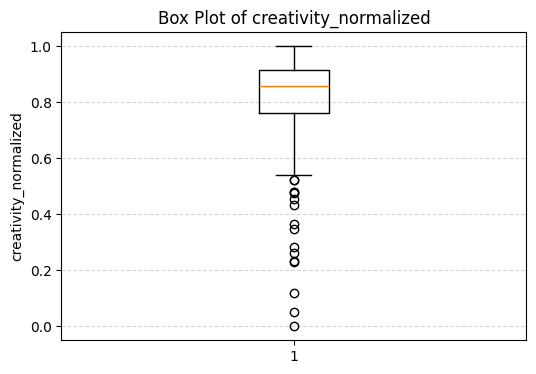

In [289]:
plt.figure(figsize=(6, 4))
plt.boxplot(creativity_normalized, vert=True, showfliers=True)
plt.title("Box Plot of creativity_normalized")
plt.ylabel("creativity_normalized")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [290]:
y = [1 if i>=0.8 else 0 for i in creativity_normalized]
X = np.stack((newness_normalized, surprise_normalized,value_normalized), axis=1)

In [291]:
np.sum(y)/len(y)

np.float64(0.6613756613756614)

In [292]:
percentile = (creativity_normalized <= 0.8).mean() * 100
percentile

np.float64(33.86243386243386)

In [293]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, random_state=23,stratify=y)

In [294]:
model = LogisticRegression(max_iter=10000, random_state=0,class_weight="balanced")
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,0
,solver,'lbfgs'
,max_iter,10000
,multi_class,'deprecated'


In [295]:
acc = accuracy_score(y_test,model.predict(X_test)) * 100
print(f"Test Logistic Regression model accuracy: {acc:.2f}%")
auc = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
print("Test AUC:", auc)
precision = precision_score(y_test, model.predict(X_test))
print("Test Precision:", precision)
recall = recall_score(y_test, model.predict(X_test))
print("Test Recall:", recall)
f1 = f1_score(y_test, model.predict(X_test))
print("Test F1:", f1)

Test Logistic Regression model accuracy: 52.63%
Test AUC: 0.6953846153846155
Test Precision: 0.8888888888888888
Test Recall: 0.32
Test F1: 0.47058823529411764


In [296]:
confusion_matrix(y_test, model.predict(X_test))

array([[12,  1],
       [17,  8]])

## Splines 
Splines + Balanced + Normalized (max min)

In [297]:
newness_min=np.min(newness_df)
newness_max = np.max(newness_df)
newness_normalized=(newness_df - newness_min)/(newness_max-newness_min)
surprise_min=np.min(surprise_df)
surprise_max = np.max(surprise_df)
surprise_normalized=(surprise_df - surprise_min)/(surprise_max-surprise_min)
value_min=np.min(value_df)
value_max = np.max(value_df)
value_normalized=(value_df - value_min)/(value_max-value_min)
creativity_min = np.min(creative_70)
creativity_max =np.max(creative_70)
creativity_normalized = (creative_70 - creativity_min)/(creativity_max-creativity_min)

In [298]:
print(f"Creativity Minimum: {creativity_min}. Creativity Max: {creativity_max}.")

Creativity Minimum: 0.7874627846114851. Creativity Max: 0.99027119484493.


In [299]:
y = [1 if i>=0.8 else 0 for i in creativity_normalized]
X = np.stack((newness_normalized, surprise_normalized,value_normalized), axis=1)

In [300]:
np.sum(y)/len(y)

np.float64(0.6613756613756614)

In [301]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, random_state=23,stratify=y)

In [302]:
preprocess = ColumnTransformer([
    ("spline", SplineTransformer(
        degree=3,           # cubic
        n_knots=8,          # tune with CV (e.g., 5–10 common)
        extrapolation="linear",
        include_bias=False  # avoid intercept duplication
    ), [1,2]),
], remainder="drop")

In [303]:
model = make_pipeline(
    preprocess,
    LogisticRegressionCV(cv=5, max_iter=5000, n_jobs=-1,class_weight="balanced")
)

In [304]:
model.fit(X_train, y_train)

,steps,"[('columntransformer', ...), ('logisticregressioncv', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('spline', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [305]:
y_pred = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:,1]

In [306]:
acc = accuracy_score(y_test,y_pred) * 100
print(f"Test Logistic Regression model accuracy: {acc:.2f}%")
auc = roc_auc_score(y_test, y_pred_prob )
print("Test AUC:", auc)
precision = precision_score(y_test,model.predict(X_test))
print("Test Precision:", precision)
recall = recall_score(y_test, y_pred)
print("Test Recall:", recall)
f1 = f1_score(y_test, y_pred)
print("Test F1:", f1)

Test Logistic Regression model accuracy: 63.16%
Test AUC: 0.5723076923076923
Test Precision: 0.7037037037037037
Test Recall: 0.76
Test F1: 0.7307692307692307


In [307]:
confusion_matrix(y_test, y_pred)

array([[ 5,  8],
       [ 6, 19]])

## Neural Network

In [308]:
newness_min=np.min(newness_df)
newness_max = np.max(newness_df)
newness_normalized=(newness_df - newness_min)/(newness_max-newness_min)
surprise_min=np.min(surprise_df)
surprise_max = np.max(surprise_df)
surprise_normalized=(surprise_df - surprise_min)/(surprise_max-surprise_min)
value_min=np.min(value_df)
value_max = np.max(value_df)
value_normalized=(value_df - value_min)/(value_max-value_min)
creativity_min = np.min(creative_70)
creativity_max =np.max(creative_70)
creativity_normalized = (creative_70 - creativity_min)/(creativity_max-creativity_min)

In [309]:
constant = np.ones(len(surprise_df))

In [310]:
y = [1 if i>=0.8 else 0 for i in creativity_normalized]
X = np.stack((newness_normalized, surprise_normalized,value_normalized), axis=1)

In [311]:
np.sum(y)/len(y)

np.float64(0.6613756613756614)

In [312]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, random_state=23,stratify=y)

In [313]:
alphas = [1e-6,3e-6,5e-6,7e-6,9e-6,1e-5]
layers=[(4,4),(4,8),(8,8),(8,16),(16,16),(16,32)]

In [314]:
result=[]
best_alpha=None
best_layer=None
best_score=None
for alpha in alphas:
    for layer in layers:
        model = MLPClassifier(solver='lbfgs', alpha=alpha,
                    hidden_layer_sizes=layer, random_state=1,max_iter=5000)
        X_train1, X_val, y_train1, y_val = train_test_split(X_train,y_train, test_size=0.20, random_state=23,stratify=y_train)
        sample_weights = compute_sample_weight(class_weight='balanced', y=y_train1)
        
        model.fit(X_train1, y_train1, sample_weight = sample_weights)

        
            
        y_pred = model.predict(X_val)
        y_pred_prob = model.predict_proba(X_val)[:,1]
        acc = accuracy_score(y_val,y_pred) * 100
        #print(f"Test Logistic Regression model accuracy: {acc:.2f}%")
        auc = roc_auc_score(y_val, y_pred_prob)
        #print("Test AUC:", auc)
        precision = precision_score(y_val,y_pred)
        #print("Test Precision:", precision)
        recall = recall_score(y_val, y_pred)
        #print("Test Recall:", recall)
        f1 = f1_score(y_val, y_pred)

        if best_alpha==None:
            best_alpha = alpha
            best_layer = layer
            best_score = auc
        elif best_score > auc:
            best_alpha = alpha
            best_layer = layer
            best_score = auc
            
        
        result.append({'alpha':alpha,'layer':layer,'acc':acc,'auc':auc,'precision':precision,'recall':recall,'f1':f1,'conf_matrix':confusion_matrix(y_val, y_pred)})
        #print("Test F1:", f1)

In [315]:
model = MLPClassifier(solver='lbfgs', alpha=best_alpha,
                    hidden_layer_sizes=best_layer, random_state=1,max_iter=5000)
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)
model.fit(X_train, y_train, sample_weight = sample_weights)
y_pred = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:,1]
acc = accuracy_score(y_test,y_pred) * 100
print(f"Test Logistic Regression model accuracy: {acc:.2f}%")
auc = roc_auc_score(y_test, y_pred_prob)
print("Test AUC:", auc)
precision = precision_score(y_test,y_pred)
print("Test Precision:", precision)
recall = recall_score(y_test, y_pred)
print("Test Recall:", recall)
f1 = f1_score(y_test, y_pred)
print("Test F1:", f1)
confusion_matrix(y_test, y_pred)

Test Logistic Regression model accuracy: 42.11%
Test AUC: 0.5107692307692308
Test Precision: 0.6666666666666666
Test Recall: 0.24
Test F1: 0.35294117647058826


array([[10,  3],
       [19,  6]])

In [316]:
confusion_matrix(y_test, y_pred)

array([[10,  3],
       [19,  6]])

In [317]:
df = pd.DataFrame(result)
df

,alpha,layer,acc,auc,precision,recall,f1,conf_matrix
0,0.000001,"(4, 4)",51.612903,0.471429,0.687500,0.523810,0.594595,"[[5, 5], [10, 11]]"
1,0.000001,"(4, 8)",61.290323,0.542857,0.736842,0.666667,0.700000,"[[5, 5], [7, 14]]"
2,0.000001,"(8, 8)",51.612903,0.295238,0.650000,0.619048,0.634146,"[[3, 7], [8, 13]]"
3,0.000001,"(8, 16)",45.161290,0.442857,0.642857,0.428571,0.514286,"[[5, 5], [12, 9]]"
4,0.000001,"(16, 16)",51.612903,0.428571,0.650000,0.619048,0.634146,"[[3, 7], [8, 13]]"
5,0.000001,"(16, 32)",45.161290,0.442857,0.611111,0.523810,0.564103,"[[3, 7], [10, 11]]"
6,0.000003,"(4, 4)",51.612903,0.471429,0.687500,0.523810,0.594595,"[[5, 5], [10, 11]]"
7,0.000003,"(4, 8)",61.290323,0.557143,0.736842,0.666667,0.700000,"[[5, 5], [7, 14]]"
8,0.000003,"(8, 8)",32.258065,0.195238,0.500000,0.333333,0.400000,"[[3, 7], [14, 7]]"
9,0.000003,"(8, 16)",51.612903,0.514286,0.687500,0.523810,0.594595,"[[5, 5], [10, 11]]"


# Cut off 0.60

## Basic
Balanced + Normalized (max min)

In [318]:
newness_min=np.min(newness_df)
newness_max = np.max(newness_df)
newness_normalized=(newness_df - newness_min)/(newness_max-newness_min)

In [319]:
surprise_min=np.min(surprise_df)
surprise_max = np.max(surprise_df)
surprise_normalized=(surprise_df - surprise_min)/(surprise_max-surprise_min)

In [320]:
value_min=np.min(value_df)
value_max = np.max(value_df)
value_normalized=(value_df - value_min)/(value_max-value_min)

In [321]:
creativity_min = np.min(creative_70)
creativity_max =np.max(creative_70)
creativity_normalized = (creative_70 - creativity_min)/(creativity_max-creativity_min)

In [322]:
print(f"Creativity Minimum: {creativity_min}. Creativity Max: {creativity_max}.")

Creativity Minimum: 0.7874627846114851. Creativity Max: 0.99027119484493.


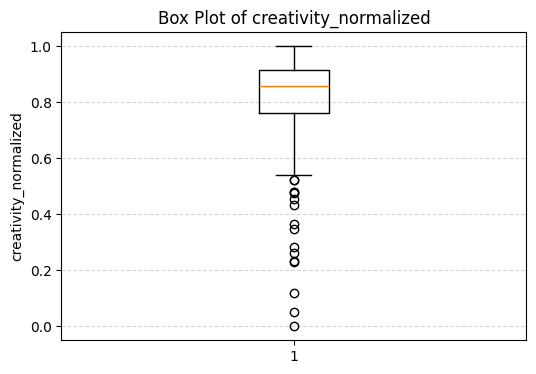

In [323]:
plt.figure(figsize=(6, 4))
plt.boxplot(creativity_normalized, vert=True, showfliers=True)
plt.title("Box Plot of creativity_normalized")
plt.ylabel("creativity_normalized")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [324]:
y = [1 if i>=0.6 else 0 for i in creativity_normalized]
X = np.stack((newness_normalized, surprise_normalized,value_normalized), axis=1)

In [325]:
np.sum(y)/len(y)

np.float64(0.873015873015873)

In [326]:
percentile = (creativity_normalized <= 0.6).mean() * 100
percentile

np.float64(12.698412698412698)

In [327]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, random_state=23,stratify=y)

In [328]:
model = LogisticRegression(max_iter=10000, random_state=0,class_weight="balanced")
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,0
,solver,'lbfgs'
,max_iter,10000
,multi_class,'deprecated'


In [329]:
acc = accuracy_score(y_test,model.predict(X_test)) * 100
print(f"Test Logistic Regression model accuracy: {acc:.2f}%")
auc = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
print("Test AUC:", auc)
precision = precision_score(y_test, model.predict(X_test))
print("Test Precision:", precision)
recall = recall_score(y_test, model.predict(X_test))
print("Test Recall:", recall)
f1 = f1_score(y_test, model.predict(X_test))
print("Test F1:", f1)

Test Logistic Regression model accuracy: 47.37%
Test AUC: 0.8606060606060606
Test Precision: 1.0
Test Recall: 0.3939393939393939
Test F1: 0.5652173913043478


In [330]:
confusion_matrix(y_test, model.predict(X_test))

array([[ 5,  0],
       [20, 13]])

## Splines 
Splines + Balanced + Normalized (max min)

In [331]:
newness_min=np.min(newness_df)
newness_max = np.max(newness_df)
newness_normalized=(newness_df - newness_min)/(newness_max-newness_min)
surprise_min=np.min(surprise_df)
surprise_max = np.max(surprise_df)
surprise_normalized=(surprise_df - surprise_min)/(surprise_max-surprise_min)
value_min=np.min(value_df)
value_max = np.max(value_df)
value_normalized=(value_df - value_min)/(value_max-value_min)
creativity_min = np.min(creative_70)
creativity_max =np.max(creative_70)
creativity_normalized = (creative_70 - creativity_min)/(creativity_max-creativity_min)

In [332]:
print(f"Creativity Minimum: {creativity_min}. Creativity Max: {creativity_max}.")

Creativity Minimum: 0.7874627846114851. Creativity Max: 0.99027119484493.


In [333]:
y = [1 if i>=0.6 else 0 for i in creativity_normalized]
X = np.stack((newness_normalized, surprise_normalized,value_normalized), axis=1)

In [334]:
np.sum(y)/len(y)

np.float64(0.873015873015873)

In [335]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, random_state=23,stratify=y)

In [336]:
preprocess = ColumnTransformer([
    ("spline", SplineTransformer(
        degree=3,           # cubic
        n_knots=8,          # tune with CV (e.g., 5–10 common)
        extrapolation="linear",
        include_bias=False  # avoid intercept duplication
    ), [1,2]),
], remainder="drop")

In [337]:
model = make_pipeline(
    preprocess,
    LogisticRegressionCV(cv=5, max_iter=5000, n_jobs=-1,class_weight="balanced")
)

In [338]:
model.fit(X_train, y_train)

,steps,"[('columntransformer', ...), ('logisticregressioncv', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('spline', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [339]:
y_pred = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:,1]

In [340]:
acc = accuracy_score(y_test,y_pred) * 100
print(f"Test Logistic Regression model accuracy: {acc:.2f}%")
auc = roc_auc_score(y_test, y_pred_prob )
print("Test AUC:", auc)
precision = precision_score(y_test,model.predict(X_test))
print("Test Precision:", precision)
recall = recall_score(y_test, y_pred)
print("Test Recall:", recall)
f1 = f1_score(y_test, y_pred)
print("Test F1:", f1)

Test Logistic Regression model accuracy: 86.84%
Test AUC: 0.47878787878787876
Test Precision: 0.868421052631579
Test Recall: 1.0
Test F1: 0.9295774647887324


In [341]:
confusion_matrix(y_test, y_pred)

array([[ 0,  5],
       [ 0, 33]])

## Neural Network

In [342]:
newness_min=np.min(newness_df)
newness_max = np.max(newness_df)
newness_normalized=(newness_df - newness_min)/(newness_max-newness_min)
surprise_min=np.min(surprise_df)
surprise_max = np.max(surprise_df)
surprise_normalized=(surprise_df - surprise_min)/(surprise_max-surprise_min)
value_min=np.min(value_df)
value_max = np.max(value_df)
value_normalized=(value_df - value_min)/(value_max-value_min)
creativity_min = np.min(creative_70)
creativity_max =np.max(creative_70)
creativity_normalized = (creative_70 - creativity_min)/(creativity_max-creativity_min)

In [343]:
constant = np.ones(len(surprise_df))

In [344]:
y = [1 if i>=0.6 else 0 for i in creativity_normalized]
X = np.stack((newness_normalized, surprise_normalized,value_normalized), axis=1)

In [345]:
np.sum(y)/len(y)

np.float64(0.873015873015873)

In [346]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, random_state=23,stratify=y)

In [347]:
alphas = [1e-6,3e-6,5e-6,7e-6,9e-6,1e-5]
layers=[(4,4),(4,8),(8,8),(8,16),(16,16),(16,32)]

In [348]:
result=[]
best_alpha=None
best_layer=None
best_score=None
for alpha in alphas:
    for layer in layers:
        model = MLPClassifier(solver='lbfgs', alpha=alpha,
                    hidden_layer_sizes=layer, random_state=1,max_iter=5000)
        X_train1, X_val, y_train1, y_val = train_test_split(X_train,y_train, test_size=0.20, random_state=23,stratify=y_train)
        sample_weights = compute_sample_weight(class_weight='balanced', y=y_train1)
        
        model.fit(X_train1, y_train1, sample_weight = sample_weights)

        
            
        y_pred = model.predict(X_val)
        y_pred_prob = model.predict_proba(X_val)[:,1]
        acc = accuracy_score(y_val,y_pred) * 100
        #print(f"Test Logistic Regression model accuracy: {acc:.2f}%")
        auc = roc_auc_score(y_val, y_pred_prob)
        #print("Test AUC:", auc)
        precision = precision_score(y_val,y_pred)
        #print("Test Precision:", precision)
        recall = recall_score(y_val, y_pred)
        #print("Test Recall:", recall)
        f1 = f1_score(y_val, y_pred)

        if best_alpha==None:
            best_alpha = alpha
            best_layer = layer
            best_score = auc
        elif best_score > auc:
            best_alpha = alpha
            best_layer = layer
            best_score = auc
            
        
        result.append({'alpha':alpha,'layer':layer,'acc':acc,'auc':auc,'precision':precision,'recall':recall,'f1':f1,'conf_matrix':confusion_matrix(y_val, y_pred)})
        #print("Test F1:", f1)

In [349]:
model = MLPClassifier(solver='lbfgs', alpha=best_alpha,
                    hidden_layer_sizes=best_layer, random_state=1,max_iter=5000)
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)
model.fit(X_train, y_train, sample_weight = sample_weights)
y_pred = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:,1]
acc = accuracy_score(y_test,y_pred) * 100
print(f"Test Logistic Regression model accuracy: {acc:.2f}%")
auc = roc_auc_score(y_test, y_pred_prob)
print("Test AUC:", auc)
precision = precision_score(y_test,y_pred)
print("Test Precision:", precision)
recall = recall_score(y_test, y_pred)
print("Test Recall:", recall)
f1 = f1_score(y_test, y_pred)
print("Test F1:", f1)
confusion_matrix(y_test, y_pred)

Test Logistic Regression model accuracy: 55.26%
Test AUC: 0.8666666666666667
Test Precision: 1.0
Test Recall: 0.48484848484848486
Test F1: 0.6530612244897959


array([[ 5,  0],
       [17, 16]])

In [350]:
df = pd.DataFrame(result)
df

,alpha,layer,acc,auc,precision,recall,f1,conf_matrix
0,0.000001,"(4, 4)",54.838710,0.564815,0.842105,0.592593,0.695652,"[[1, 3], [11, 16]]"
1,0.000001,"(4, 8)",70.967742,0.546296,0.875000,0.777778,0.823529,"[[1, 3], [6, 21]]"
2,0.000001,"(8, 8)",67.741935,0.462963,0.904762,0.703704,0.791667,"[[2, 2], [8, 19]]"
3,0.000001,"(8, 16)",54.838710,0.472222,0.842105,0.592593,0.695652,"[[1, 3], [11, 16]]"
4,0.000001,"(16, 16)",58.064516,0.444444,0.850000,0.629630,0.723404,"[[1, 3], [10, 17]]"
5,0.000001,"(16, 32)",54.838710,0.620370,0.882353,0.555556,0.681818,"[[2, 2], [12, 15]]"
6,0.000003,"(4, 4)",51.612903,0.555556,0.875000,0.518519,0.651163,"[[2, 2], [13, 14]]"
7,0.000003,"(4, 8)",64.516129,0.546296,0.900000,0.666667,0.765957,"[[2, 2], [9, 18]]"
8,0.000003,"(8, 8)",67.741935,0.462963,0.904762,0.703704,0.791667,"[[2, 2], [8, 19]]"
9,0.000003,"(8, 16)",64.516129,0.509259,0.863636,0.703704,0.775510,"[[1, 3], [8, 19]]"


# Cut off 0.5

## Basic
Balanced + Normalized (max min)

In [351]:
newness_min=np.min(newness_df)
newness_max = np.max(newness_df)
newness_normalized=(newness_df - newness_min)/(newness_max-newness_min)

In [352]:
surprise_min=np.min(surprise_df)
surprise_max = np.max(surprise_df)
surprise_normalized=(surprise_df - surprise_min)/(surprise_max-surprise_min)

In [353]:
value_min=np.min(value_df)
value_max = np.max(value_df)
value_normalized=(value_df - value_min)/(value_max-value_min)

In [354]:
creativity_min = np.min(creative_70)
creativity_max =np.max(creative_70)
creativity_normalized = (creative_70 - creativity_min)/(creativity_max-creativity_min)

In [355]:
print(f"Creativity Minimum: {creativity_min}. Creativity Max: {creativity_max}.")

Creativity Minimum: 0.7874627846114851. Creativity Max: 0.99027119484493.


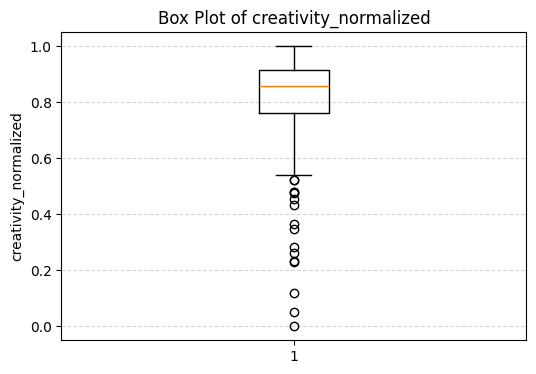

In [356]:
plt.figure(figsize=(6, 4))
plt.boxplot(creativity_normalized, vert=True, showfliers=True)
plt.title("Box Plot of creativity_normalized")
plt.ylabel("creativity_normalized")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [357]:
y = [1 if i>=0.5 else 0 for i in creativity_normalized]
X = np.stack((newness_normalized, surprise_normalized,value_normalized), axis=1)

In [358]:
percentile = (creativity_normalized <= 0.5).mean() * 100
percentile

np.float64(7.4074074074074066)

In [359]:
np.sum(y)/len(y)

np.float64(0.9259259259259259)

In [360]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, random_state=23,stratify=y)

In [361]:
model = LogisticRegression(max_iter=10000, random_state=0,class_weight="balanced")
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,0
,solver,'lbfgs'
,max_iter,10000
,multi_class,'deprecated'


In [362]:
print(model.classes_)

[0 1]


In [363]:
acc = accuracy_score(y_test,model.predict(X_test)) * 100
print(f"Test Logistic Regression model accuracy: {acc:.2f}%")
auc = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
print("Test AUC:", auc)
precision = precision_score(y_test, model.predict(X_test))
print("Test Precision:", precision)
recall = recall_score(y_test, model.predict(X_test))
print("Test Recall:", recall)
f1 = f1_score(y_test, model.predict(X_test))
print("Test F1:", f1)

Test Logistic Regression model accuracy: 44.74%
Test AUC: 0.30476190476190473
Test Precision: 0.85
Test Recall: 0.4857142857142857
Test F1: 0.6181818181818182


In [364]:
confusion_matrix(y_test, model.predict(X_test))

array([[ 0,  3],
       [18, 17]])

## Splines 
Splines + Balanced + Normalized (max min)

In [365]:
newness_min=np.min(newness_df)
newness_max = np.max(newness_df)
newness_normalized=(newness_df - newness_min)/(newness_max-newness_min)
surprise_min=np.min(surprise_df)
surprise_max = np.max(surprise_df)
surprise_normalized=(surprise_df - surprise_min)/(surprise_max-surprise_min)
value_min=np.min(value_df)
value_max = np.max(value_df)
value_normalized=(value_df - value_min)/(value_max-value_min)
creativity_min = np.min(creative_70)
creativity_max =np.max(creative_70)
creativity_normalized = (creative_70 - creativity_min)/(creativity_max-creativity_min)

In [366]:
print(f"Creativity Minimum: {creativity_min}. Creativity Max: {creativity_max}.")

Creativity Minimum: 0.7874627846114851. Creativity Max: 0.99027119484493.


In [367]:
y = [1 if i>=0.5 else 0 for i in creativity_normalized]
X = np.stack((newness_normalized, surprise_normalized,value_normalized), axis=1)

In [368]:
np.sum(y)/len(y)

np.float64(0.9259259259259259)

In [369]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, random_state=23,stratify=y)

In [370]:
preprocess = ColumnTransformer([
    ("spline", SplineTransformer(
        degree=3,           # cubic
        n_knots=8,          # tune with CV (e.g., 5–10 common)
        extrapolation="linear",
        include_bias=False  # avoid intercept duplication
    ), [1,2]),
], remainder="drop")

In [371]:
model = make_pipeline(
    preprocess,
    LogisticRegressionCV(cv=5, max_iter=5000, n_jobs=-1,class_weight="balanced")
)

In [372]:
model.fit(X_train, y_train)

,steps,"[('columntransformer', ...), ('logisticregressioncv', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('spline', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [373]:
y_pred = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:,1]

In [374]:
acc = accuracy_score(y_test,y_pred) * 100
print(f"Test Logistic Regression model accuracy: {acc:.2f}%")
auc = roc_auc_score(y_test, y_pred_prob )
print("Test AUC:", auc)
precision = precision_score(y_test,model.predict(X_test))
print("Test Precision:", precision)
recall = recall_score(y_test, y_pred)
print("Test Recall:", recall)
f1 = f1_score(y_test, y_pred)
print("Test F1:", f1)

Test Logistic Regression model accuracy: 52.63%
Test AUC: 0.5238095238095238
Test Precision: 0.9047619047619048
Test Recall: 0.5428571428571428
Test F1: 0.6785714285714286


In [375]:
confusion_matrix(y_test, y_pred)

array([[ 1,  2],
       [16, 19]])

## Neural Network

In [376]:
newness_min=np.min(newness_df)
newness_max = np.max(newness_df)
newness_normalized=(newness_df - newness_min)/(newness_max-newness_min)
surprise_min=np.min(surprise_df)
surprise_max = np.max(surprise_df)
surprise_normalized=(surprise_df - surprise_min)/(surprise_max-surprise_min)
value_min=np.min(value_df)
value_max = np.max(value_df)
value_normalized=(value_df - value_min)/(value_max-value_min)
creativity_min = np.min(creative_70)
creativity_max =np.max(creative_70)
creativity_normalized = (creative_70 - creativity_min)/(creativity_max-creativity_min)

In [377]:
constant = np.ones(len(surprise_df))

In [378]:
y = [1 if i>=0.5 else 0 for i in creativity_normalized]
X = np.stack((newness_normalized, surprise_normalized,value_normalized), axis=1)

In [379]:
np.sum(y)/len(y)

np.float64(0.9259259259259259)

In [380]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, random_state=23,stratify=y)

In [381]:
alphas = [1e-6,3e-6,5e-6,7e-6,9e-6,1e-5]
layers=[(4,4),(4,8),(8,8),(8,16),(16,16),(16,32)]

In [382]:
result=[]
best_alpha=None
best_layer=None
best_score=None
for alpha in alphas:
    for layer in layers:
        model = MLPClassifier(solver='lbfgs', alpha=alpha,
                    hidden_layer_sizes=layer, random_state=1,max_iter=5000)
        X_train1, X_val, y_train1, y_val = train_test_split(X_train,y_train, test_size=0.20, random_state=23,stratify=y_train)
        sample_weights = compute_sample_weight(class_weight='balanced', y=y_train1)
        
        model.fit(X_train1, y_train1, sample_weight = sample_weights)

        
            
        y_pred = model.predict(X_val)
        y_pred_prob = model.predict_proba(X_val)[:,1]
        acc = accuracy_score(y_val,y_pred) * 100
        #print(f"Test Logistic Regression model accuracy: {acc:.2f}%")
        auc = roc_auc_score(y_val, y_pred_prob)
        #print("Test AUC:", auc)
        precision = precision_score(y_val,y_pred)
        #print("Test Precision:", precision)
        recall = recall_score(y_val, y_pred)
        #print("Test Recall:", recall)
        f1 = f1_score(y_val, y_pred)

        if best_alpha==None:
            best_alpha = alpha
            best_layer = layer
            best_score = auc
        elif best_score > auc:
            best_alpha = alpha
            best_layer = layer
            best_score = auc
            
        
        result.append({'alpha':alpha,'layer':layer,'acc':acc,'auc':auc,'precision':precision,'recall':recall,'f1':f1,'conf_matrix':confusion_matrix(y_val, y_pred)})
        #print("Test F1:", f1)



/opt/anaconda3/envs/Creativity/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 75 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


In [383]:
model = MLPClassifier(solver='lbfgs', alpha=best_alpha,
                    hidden_layer_sizes=best_layer, random_state=1,max_iter=5000)
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)
model.fit(X_train, y_train, sample_weight = sample_weights)
y_pred = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:,1]
acc = accuracy_score(y_test,y_pred) * 100
print(f"Test Logistic Regression model accuracy: {acc:.2f}%")
auc = roc_auc_score(y_test, y_pred_prob)
print("Test AUC:", auc)
precision = precision_score(y_test,y_pred)
print("Test Precision:", precision)
recall = recall_score(y_test, y_pred)
print("Test Recall:", recall)
f1 = f1_score(y_test, y_pred)
print("Test F1:", f1)
confusion_matrix(y_test, y_pred)

Test Logistic Regression model accuracy: 39.47%
Test AUC: 0.6
Test Precision: 0.9285714285714286
Test Recall: 0.37142857142857144
Test F1: 0.5306122448979592


array([[ 2,  1],
       [22, 13]])

In [231]:
df = pd.DataFrame(result)
df

,alpha,layer,acc,auc,precision,recall,f1,conf_matrix
0,0.000001,"(4, 4)",41.935484,0.422414,0.923077,0.413793,0.571429,"[[1, 1], [17, 12]]"
1,0.000001,"(4, 8)",67.741935,0.655172,0.952381,0.689655,0.800000,"[[1, 1], [9, 20]]"
2,0.000001,"(8, 8)",70.967742,0.689655,0.954545,0.724138,0.823529,"[[1, 1], [8, 21]]"
3,0.000001,"(8, 16)",58.064516,0.637931,0.944444,0.586207,0.723404,"[[1, 1], [12, 17]]"
4,0.000001,"(16, 16)",41.935484,0.534483,0.923077,0.413793,0.571429,"[[1, 1], [17, 12]]"
5,0.000001,"(16, 32)",58.064516,0.431034,0.944444,0.586207,0.723404,"[[1, 1], [12, 17]]"
6,0.000003,"(4, 4)",51.612903,0.482759,0.937500,0.517241,0.666667,"[[1, 1], [14, 15]]"
7,0.000003,"(4, 8)",70.967742,0.310345,0.916667,0.758621,0.830189,"[[0, 2], [7, 22]]"
8,0.000003,"(8, 8)",58.064516,0.724138,0.944444,0.586207,0.723404,"[[1, 1], [12, 17]]"
9,0.000003,"(8, 16)",58.064516,0.637931,0.944444,0.586207,0.723404,"[[1, 1], [12, 17]]"


# What if We renormalize the data

In [232]:
creativity_min = np.min(creative_70)
creativity_max =np.max(creative_70)
creativity_normalized = (creative_70 - creativity_min)/(creativity_max-creativity_min)

In [233]:
print(f"Creativity Minimum: {creativity_min}. Creativity Max: {creativity_max}.")

Creativity Minimum: 0.7874627846114851. Creativity Max: 0.99027119484493.


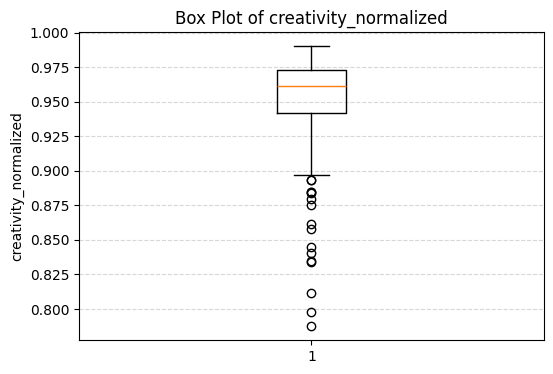

In [234]:
plt.figure(figsize=(6, 4))
plt.boxplot(creative_70, vert=True, showfliers=True)
plt.title("Box Plot of creativity_normalized")
plt.ylabel("creativity_normalized")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [153]:
creative = np.array(creativity_normalized, dtype=float)
Q1 = np.percentile(creative, 25)
Q3 = np.percentile(creative, 75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
creative_outliers =creative[(creative < lower_bound) | (creative > upper_bound)]

In [154]:
np.max(creative_outliers)

np.float64(0.5220632292415921)

In [155]:
creative_new = creative[creative>=np.max(creative_outliers)]

In [156]:
creativity_min = np.min(creative_new)
creativity_max =np.max(creative_new)
creativity_normalized = (creative_new - creativity_min)/(creativity_max-creativity_min)

In [157]:
np.min(creativity_normalized)

np.float64(0.0)

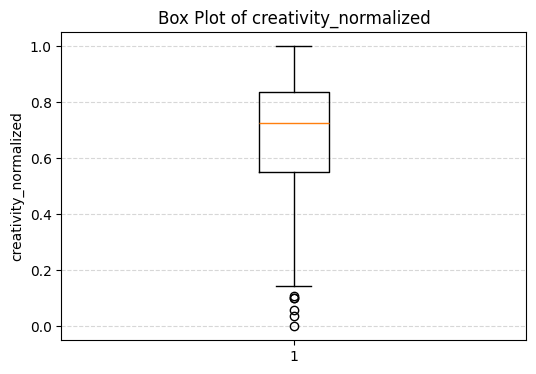

In [158]:
plt.figure(figsize=(6, 4))
plt.boxplot(creativity_normalized, vert=True, showfliers=True)
plt.title("Box Plot of creativity_normalized")
plt.ylabel("creativity_normalized")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [159]:
np.percentile(creativity_normalized, 50)

np.float64(0.7273087987159602)

## Cut off 0.7

### Basic
Balanced + Normalized (max min)

In [160]:
newness_df_new = newness_df[creative>=np.max(creative_outliers)]

In [161]:
newness_df_new.shape

(174,)

In [162]:
newness_min=np.min(newness_df_new)
newness_max = np.max(newness_df_new)
newness_normalized=(newness_df_new - newness_min)/(newness_max-newness_min)

In [163]:
surprise_df_new = surprise_df[creative>=np.max(creative_outliers)]

In [164]:
surprise_df_new.shape

(174,)

In [165]:
surprise_min=np.min(surprise_df_new)
surprise_max = np.max(surprise_df_new)
surprise_normalized=(surprise_df_new - surprise_min)/(surprise_max-surprise_min)

In [166]:
value_df_new = value_df[creative>=np.max(creative_outliers)]

In [167]:
value_df_new.shape

(174,)

In [168]:
value_min=np.min(value_df_new)
value_max = np.max(value_df_new)
value_normalized=(value_df_new - value_min)/(value_max-value_min)

In [169]:
creativity_min = np.min(creative_new)
creativity_max =np.max(creative_new)
creativity_normalized = (creative_new - creativity_min)/(creativity_max-creativity_min)

In [170]:
creativity_normalized.shape

(174,)

In [171]:
print(f"Creativity Minimum: {creativity_min}. Creativity Max: {creativity_max}.")

Creativity Minimum: 0.5220632292415921. Creativity Max: 1.0.


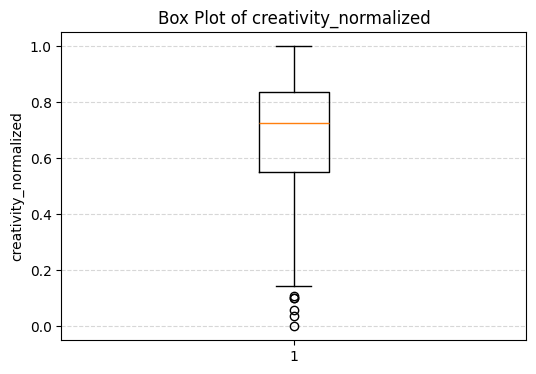

In [172]:
plt.figure(figsize=(6, 4))
plt.boxplot(creativity_normalized, vert=True, showfliers=True)
plt.title("Box Plot of creativity_normalized")
plt.ylabel("creativity_normalized")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [173]:
y = [1 if i>=0.7 else 0 for i in creativity_normalized]
X = np.stack((newness_normalized, surprise_normalized,value_normalized), axis=1)

In [174]:
np.sum(y)/len(y)

np.float64(0.5517241379310345)

In [175]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, random_state=23,stratify=y)

In [176]:
model = LogisticRegression(max_iter=10000, random_state=0,class_weight="balanced")
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,0
,solver,'lbfgs'
,max_iter,10000
,multi_class,'deprecated'


In [177]:
acc = accuracy_score(y_test,model.predict(X_test)) * 100
print(f"Test Logistic Regression model accuracy: {acc:.2f}%")
auc = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
print("Test AUC:", auc)
precision = precision_score(y_test, model.predict(X_test))
print("Test Precision:", precision)
recall = recall_score(y_test, model.predict(X_test))
print("Test Recall:", recall)
f1 = f1_score(y_test, model.predict(X_test))
print("Test F1:", f1)

Test Logistic Regression model accuracy: 45.71%
Test AUC: 0.5263157894736842
Test Precision: 0.5
Test Recall: 0.21052631578947367
Test F1: 0.2962962962962963


In [178]:
confusion_matrix(y_test, model.predict(X_test))

array([[12,  4],
       [15,  4]])

## Splines 
Splines + Balanced + Normalized (max min)

In [179]:
newness_min=np.min(newness_df)
newness_max = np.max(newness_df)
newness_normalized=(newness_df - newness_min)/(newness_max-newness_min)
surprise_min=np.min(surprise_df)
surprise_max = np.max(surprise_df)
surprise_normalized=(surprise_df - surprise_min)/(surprise_max-surprise_min)
value_min=np.min(value_df)
value_max = np.max(value_df)
value_normalized=(value_df - value_min)/(value_max-value_min)
creativity_min = np.min(creative_70)
creativity_max =np.max(creative_70)
creativity_normalized = (creative_70 - creativity_min)/(creativity_max-creativity_min)

In [180]:
print(f"Creativity Minimum: {creativity_min}. Creativity Max: {creativity_max}.")

Creativity Minimum: 0.7874627846114851. Creativity Max: 0.99027119484493.


In [181]:
y = [1 if i>=0.7 else 0 for i in creativity_normalized]
X = np.stack((newness_normalized, surprise_normalized,value_normalized), axis=1)

In [182]:
np.sum(y)/len(y)

np.float64(0.8201058201058201)

In [183]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, random_state=23,stratify=y)

In [184]:
preprocess = ColumnTransformer([
    ("spline", SplineTransformer(
        degree=3,           # cubic
        n_knots=8,          # tune with CV (e.g., 5–10 common)
        extrapolation="linear",
        include_bias=False  # avoid intercept duplication
    ), [1,2]),
], remainder="drop")

In [185]:
model = make_pipeline(
    preprocess,
    LogisticRegressionCV(cv=5, max_iter=5000, n_jobs=-1,class_weight="balanced")
)

In [186]:
model.fit(X_train, y_train)

,steps,"[('columntransformer', ...), ('logisticregressioncv', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('spline', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [187]:
y_pred = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:,1]

In [188]:
acc = accuracy_score(y_test,y_pred) * 100
print(f"Test Logistic Regression model accuracy: {acc:.2f}%")
auc = roc_auc_score(y_test, y_pred_prob )
print("Test AUC:", auc)
precision = precision_score(y_test,model.predict(X_test))
print("Test Precision:", precision)
recall = recall_score(y_test, y_pred)
print("Test Recall:", recall)
f1 = f1_score(y_test, y_pred)
print("Test F1:", f1)

Test Logistic Regression model accuracy: 52.63%
Test AUC: 0.576036866359447
Test Precision: 0.8095238095238095
Test Recall: 0.5483870967741935
Test F1: 0.6538461538461539


In [189]:
confusion_matrix(y_test, y_pred)

array([[ 3,  4],
       [14, 17]])

## Neural Network

In [190]:
newness_min=np.min(newness_df)
newness_max = np.max(newness_df)
newness_normalized=(newness_df - newness_min)/(newness_max-newness_min)
surprise_min=np.min(surprise_df)
surprise_max = np.max(surprise_df)
surprise_normalized=(surprise_df - surprise_min)/(surprise_max-surprise_min)
value_min=np.min(value_df)
value_max = np.max(value_df)
value_normalized=(value_df - value_min)/(value_max-value_min)
creativity_min = np.min(creative_70)
creativity_max =np.max(creative_70)
creativity_normalized = (creative_70 - creativity_min)/(creativity_max-creativity_min)

In [191]:
constant = np.ones(len(surprise_df))

In [192]:
y = [1 if i>=0.7 else 0 for i in creativity_normalized]
X = np.stack((newness_normalized, surprise_normalized,value_normalized), axis=1)

In [193]:
np.sum(y)/len(y)

np.float64(0.8201058201058201)

In [194]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, random_state=23,stratify=y)

In [195]:
alphas = [1e-6,3e-6,5e-6,7e-6,9e-6,1e-5]
layers=[(4,4),(4,8),(8,8),(8,16),(16,16),(16,32)]

In [196]:
result=[]
for alpha in alphas:
    for layer in layers:
        model = MLPClassifier(solver='lbfgs', alpha=alpha,
                    hidden_layer_sizes=layer, random_state=1,max_iter=5000)
        sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)
        model.fit(X_train, y_train, sample_weight = sample_weights)
        y_pred = model.predict(X_test)
        y_pred_prob = model.predict_proba(X_test)[:,1]
        acc = accuracy_score(y_test,y_pred) * 100
        #print(f"Test Logistic Regression model accuracy: {acc:.2f}%")
        auc = roc_auc_score(y_test, y_pred_prob)
        #print("Test AUC:", auc)
        precision = precision_score(y_test,y_pred)
        #print("Test Precision:", precision)
        recall = recall_score(y_test, y_pred)
        #print("Test Recall:", recall)
        f1 = f1_score(y_test, y_pred)
        
        result.append({'alpha':alpha,'layer':layer,'acc':acc,'auc':auc,'precision':precision,'recall':recall,'f1':f1,'conf_matrix':confusion_matrix(y_test, y_pred)})
        #print("Test F1:", f1)


In [197]:
df = pd.DataFrame(result)
df

,alpha,layer,acc,auc,precision,recall,f1,conf_matrix
0,0.000001,"(4, 4)",50.000000,0.451613,0.800000,0.516129,0.627451,"[[3, 4], [15, 16]]"
1,0.000001,"(4, 8)",57.894737,0.373272,0.758621,0.709677,0.733333,"[[0, 7], [9, 22]]"
2,0.000001,"(8, 8)",65.789474,0.470046,0.846154,0.709677,0.771930,"[[3, 4], [9, 22]]"
3,0.000001,"(8, 16)",50.000000,0.511521,0.800000,0.516129,0.627451,"[[3, 4], [15, 16]]"
4,0.000001,"(16, 16)",50.000000,0.391705,0.772727,0.548387,0.641509,"[[2, 5], [14, 17]]"
5,0.000001,"(16, 32)",63.157895,0.548387,0.814815,0.709677,0.758621,"[[2, 5], [9, 22]]"
6,0.000003,"(4, 4)",50.000000,0.451613,0.800000,0.516129,0.627451,"[[3, 4], [15, 16]]"
7,0.000003,"(4, 8)",50.000000,0.474654,0.772727,0.548387,0.641509,"[[2, 5], [14, 17]]"
8,0.000003,"(8, 8)",65.789474,0.456221,0.846154,0.709677,0.771930,"[[3, 4], [9, 22]]"
9,0.000003,"(8, 16)",52.631579,0.428571,0.809524,0.548387,0.653846,"[[3, 4], [14, 17]]"
